In [1]:
import torch
from torchvision import datasets
import numpy as np
import sklearn
from sklearn.model_selection import StratifiedKFold
import logging
import math
import random
from sklearn.mixture import GaussianMixture
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import kstest, anderson_ksamp, cumfreq, ks_2samp, cramervonmises, chisquare, entropy, wasserstein_distance
# from statsmodels.distributions.empirical_distribution import ECDF

In [2]:
def get_data(path=None):
    mnist_train: datasets = datasets.MNIST(root=path, train=True, download=True, transform=None)
    mnist_test: datasets = datasets.MNIST(root=path, train=False, download=True, transform=None)

    x_train, y_train = mnist_train.data, mnist_train.targets
    x_test, y_test = mnist_test.data, mnist_test.targets

    return x_train, y_train, x_test, y_test

In [3]:
# function that returns a map which stores the indices of data points belonging to each label (0:9)
def parse_class_distr(data):
    class_ID_map = {}

    for ID, classes in enumerate(data):
        for cls in classes:
            if cls not in class_ID_map:
                class_ID_map[cls] = []
            class_ID_map[cls].append(ID)


def log_class_counts(y_train, subset_ID_map, logdir):
    cls_counts = {}

    for subset_i, ID in subset_ID_map.items():
        unq, unq_cnt = np.unique(y_train[ID], return_counts=True)
        tmp = {unq[i]: unq_cnt[i] for i in range(len(unq))}
        cls_counts[subset_i] = tmp

    logging.debug('Label distributions: %s' % str(cls_counts))

    return cls_counts

In [4]:
def log_class_counts(y_train, subset_ID_map, log=False):
    cls_counts = {}

    for subset_i, ID in subset_ID_map.items():
        unq, unq_cnt = np.unique(y_train[ID], return_counts=True)
        tmp = {unq[i]: unq_cnt[i] for i in range(len(unq))}
        cls_counts[subset_i] = tmp

    if log:
        logging.debug('Label distributions: %s' % str(cls_counts))

    return cls_counts

In [5]:
def map_to_prob(y_train, subset_map):
    counts = log_class_counts(y_train, subset_map)

    values = [np.array([counts.get(k).get(key) for key in counts.get(k)]) for k in counts]
    probs = [values[j] / values[j].sum() for j in range(len(values))]

    return probs

In [6]:
def partition_homo_skf(dir, n_clients, alpha=0):
    subset_ID_map = {}
    mnist_train: datasets = datasets.MNIST(root=dir, train=True, download=True, transform=None)
    x_train, y_train = mnist_train.data, mnist_train.targets
    n_train = y_train.shape[0]
    skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=42)
    subsets = []
    for train_ID, test_ID in skf.split(mnist_train, y_train):
        subsets.append(test_ID)
    for j in range(n_clients):
        # np.random.shuffle(subsets[j])
        subset_ID_map[j] = subsets[j]
    return subset_ID_map

In [7]:
def partition_hetero_dir(dir, n_clients, alpha):
    x_train, y_train, x_test, y_test = get_data(dir)
    min_size = 0
    # classes
    K = 10
    # data points
    N = y_train.shape[0]
    subset_ID_map = {}

    while min_size < 10:
        subset_ID_list = [[] for _ in range(n_clients)]
        for k in range(K):
            ids_k = np.where(y_train == k)[0]
            np.random.shuffle(ids_k)
            proportions = np.random.dirichlet(np.repeat(alpha, n_clients))
            proportions = np.array(
                [p * (len(ids_j) < N / n_clients) for p, ids_j in zip(proportions, subset_ID_list)])
            proportions = proportions / proportions.sum()
            proportions = (np.cumsum(proportions) * len(ids_k)).astype(int)[:-1]
            subset_ID_list = [ids_j + ids.tolist() for ids_j, ids in
                              zip(subset_ID_list, np.split(ids_k, proportions))]
            min_size = min([len(ids_j) for ids_j in subset_ID_list])

    for j in range(n_clients):
        np.random.shuffle(subset_ID_list[j])
        subset_ID_map[j] = subset_ID_list[j]

    return subset_ID_map

In [8]:
def partition_hetero_gaussian(dir, n_clients, alpha, bootstrap=False):
    x_train, y_train, x_test, y_test = get_data(dir)
    min_size = 0
    # classes
    K = 10
    # data points
    N = y_train.shape[0]
    subset_ID_map = {}

    def gaussian_pdf(x, mu, sig):
        return np.exp(- np.power(x - mu, 2.) / (2 * np.power(sig, 2.))) / (sig * math.sqrt(2 * math.pi))

    labels = list(set(y_train.tolist()))
    mu = 5
    sig = alpha
    proportions = np.array([gaussian_pdf(x, mu, sig) for x in labels])

    if bootstrap:
        # make sure the most frequent label always gets selected
        norm_const = 1 / max(proportions)
        proportions = [item * norm_const for item in proportions]
        prob_map = {labels[i]: proportions[i] for i in range(len(labels))}

        def shuffle_labels(map):
            max_item = max(map, key=map.get)
            max_val = map.get(max_item)
            del map[max_item]
            keys = list(map.keys())
            values = list(map.values())
            random.shuffle(values)
            new_map = {keys[i]: values[i] for i in range(len(keys))}
            new_map.update({max_item:max_val})
            return new_map

        prob_map = shuffle_labels(prob_map)

        subset_ID_list = [[] for _ in range(n_clients)]

        for k in range(K):
            sample = []

            for ID, x in enumerate(y_train.tolist):
                if random.uniform(0, 1) < float(prob_map.get(x)):
                    sample.append(ID)

            subset_ID_list[k] = sample

    else:
        while min_size < 10:
            subset_ID_list = [[] for _ in range(n_clients)]
            for k in range(K):
                ids_k = np.where(y_train == k)[0]
                np.random.shuffle(ids_k)
                proportions = np.array([gaussian_pdf(x, mu, sig) for x in labels])
                proportions = np.array(
                    [p * (len(ids_j) < N / n_clients) for p, ids_j in zip(proportions, subset_ID_list)])
                proportions = proportions / proportions.sum()
                proportions = (np.cumsum(proportions) * len(ids_k)).astype(int)[:-1]
                subset_ID_list = [ids_j + ids.tolist() for ids_j, ids in
                                  zip(subset_ID_list, np.split(ids_k, proportions))]
                min_size = min([len(ids_j) for ids_j in subset_ID_list])

    subset_ID_map = {i: subset_ID_list[i] for i in range(n_clients)}

    return subset_ID_map

In [9]:
def partition(dir, type, n_clients, alpha):
    partition_funcs = {
        "homo" : partition_homo_skf,
        "hetero-dir": partition_hetero_dir,
        "hetero-gaussian": partition_hetero_gaussian
    }
    
    try:
        partition_func = partition_funcs[type]
    except KeyError:
        raise ValueError(f"Invalid mode: {type}")

    return partition_func(dir, n_clients, alpha)

In [10]:
def visualize(path, epoch, y_train, subset_ID_map, mode_plot, mode_partitioning, alpha, save=False):
    counts = log_class_counts(y_train, subset_ID_map)

    values = [np.array([counts.get(k).get(key) for key in counts.get(k)]) for k in counts]
    values_normalized = [values[j] / values[j].sum() for j in range(len(values))]

    n_clients = len(subset_ID_map)

    title_formats = {
        "hetero-dir": "A distribution-based heterogeneous partitioning X~Dir({alpha}) with {n_clients} subsets",
        "hetero-gaussian": "A distribution-based Gaussian heterogeneous partitioning σ={alpha} with {n_clients} subsets",
        "homo": "A homogeneous partitioning with {n_clients} subsets",
    }
    main_title = title_formats.get(mode_partitioning, "")
    main_title = main_title.format(alpha=alpha, n_clients=n_clients)

    subtitle_formats = {
        "hetero_dir": "α_{epoch}={alpha}",
        "hetero-gaussian": "σ_{epoch}={alpha}",
        "homo" : ""
    }

    subtitle = subtitle_formats.get(mode_partitioning, "")
    subtitle = subtitle.format(epoch=epoch, alpha=alpha)

    if mode_plot == "heatmap":
        ax = sns.heatmap(pd.DataFrame(values_normalized), vmin=0, vmax=1, cmap=sns.cm.rocket_r)
        ax.set(xlabel="Labels", ylabel="Clients", title=main_title)
        plt.show()
    elif mode_plot == "histogram":
        dim_x = 2
        dim_y = 5
        fig, axes = plt.subplots(dim_y, dim_x)
        for j in range(len(values)):
            plt.figure(figsize=(5, 3), dpi=300)
            plt.hist(values[j], [(i - 0.5) / 2 for i in range(20)], label="Sampled dist")
            x = np.arange(-0.5, 9.5, 0.1)
            plt.xticks([i for i in range(10)])
            plt.xlabel("Label")
            plt.xlim([-1, 10])
            plt.ylabel("Entries")
            plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.show()

In [11]:
def tensor_to_csv(x_train, y_train, subset_map, epoch_num):
    for key in subset_map:
        x, y = x_train[subset_map.get(key)], y_train[subset_map.get(key)]
        df_x = pd.DataFrame(x.tolist())
        df_y = pd.DataFrame(y.tolist())
        df_x['targets'] = df_y
        df_x.rename(columns={0: 'data', "targets": "targets"})
        df_x.to_csv(f'subsets/epoch_{epoch_num}_subset_{key + 1}.csv', index=False)


In [12]:
x_train, y_train, x_test, y_test = get_data("C:/Users/Aybüke/PycharmProjects/datasets")

In [13]:
map_homo = partition("C:/Users/Aybüke/PycharmProjects/datasets", "homo", 10, 0)
map_dir_05 = partition("C:/Users/Aybüke/PycharmProjects/datasets", "hetero-dir", 10, 0.5)
map_dir_1000 = partition("C:/Users/Aybüke/PycharmProjects/datasets", "hetero-dir", 10, 1000)
map_gaussian_1 = partition("C:/Users/Aybüke/PycharmProjects/datasets", "hetero-gaussian", 10, 1)
map_gaussian_20 = partition("C:/Users/Aybüke/PycharmProjects/datasets", "hetero-gaussian", 10, 20)
map_gaussian_1000 = partition("C:/Users/Aybüke/PycharmProjects/datasets", "hetero-gaussian", 10, 1000)

In [14]:
count_homo = log_class_counts(y_train, map_homo)
count_dir_05 = log_class_counts(y_train, map_dir_05)
count_dir_1000 = log_class_counts(y_train, map_dir_1000)
count_gaussian_1 = log_class_counts(y_train, map_gaussian_1)
count_gaussian_20 = log_class_counts(y_train, map_gaussian_20)
count_gaussian_1000 = log_class_counts(y_train, map_gaussian_1000)

In [15]:
values = [np.array([count_homo.get(k).get(key) for key in count_homo.get(k)]) for k in count_homo]
counts_normalized = [values[j] / values[j].sum() for j in range(len(values))]
counts_normalized

[array([0.09866667, 0.11233333, 0.09933333, 0.10216667, 0.09733333,
        0.0905    , 0.09866667, 0.10433333, 0.0975    , 0.09916667]),
 array([0.09883333, 0.11233333, 0.09933333, 0.10216667, 0.09733333,
        0.09033333, 0.09866667, 0.10433333, 0.0975    , 0.09916667]),
 array([0.09883333, 0.11233333, 0.09933333, 0.10216667, 0.09733333,
        0.09033333, 0.09866667, 0.10433333, 0.0975    , 0.09916667]),
 array([0.09883333, 0.11233333, 0.09933333, 0.10216667, 0.09733333,
        0.09033333, 0.09866667, 0.10433333, 0.0975    , 0.09916667]),
 array([0.09866667, 0.11233333, 0.09933333, 0.10216667, 0.0975    ,
        0.09033333, 0.0985    , 0.1045    , 0.0975    , 0.09916667]),
 array([0.09866667, 0.11233333, 0.09916667, 0.10233333, 0.0975    ,
        0.09033333, 0.0985    , 0.1045    , 0.0975    , 0.09916667]),
 array([0.09866667, 0.1125    , 0.09916667, 0.10216667, 0.09733333,
        0.09033333, 0.09866667, 0.1045    , 0.0975    , 0.09916667]),
 array([0.09866667, 0.1125    , 0.

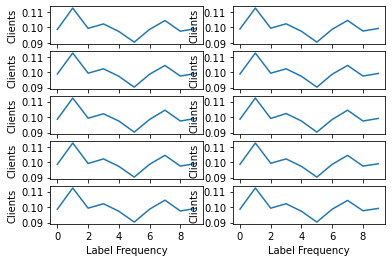

In [16]:
# homogenous
fig, axes = plt.subplots(5, 2)
for j in range(len(counts_normalized)):
    ax = sns.lineplot(counts_normalized[j], ax=axes[int(j / 2), j % 2])
    ax.set(xlabel="Label Frequency", ylabel="Clients")
plt.show()

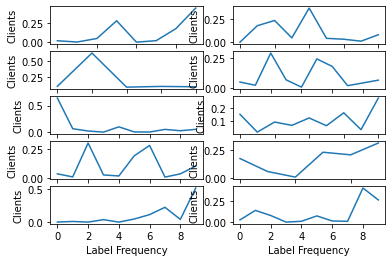

In [17]:
# heterogenous
values = [np.array([count_dir_05.get(k).get(key) for key in count_dir_05.get(k)]) for k in count_dir_05]
counts_normalized = [values[j] / values[j].sum() for j in range(len(values))]
counts_normalized

fig, axes = plt.subplots(5, 2)
for j in range(len(counts_normalized)):
    ax = sns.lineplot(counts_normalized[j], ax=axes[int(j / 2), j % 2])
    ax.set(xlabel="Label Frequency", ylabel="Clients")
plt.show()

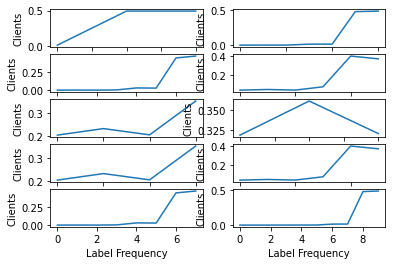

In [18]:
# gaussian ~ N(5, 0.5)
values = [np.array([count_gaussian_1.get(k).get(key) for key in count_gaussian_1.get(k)]) for k in count_gaussian_1]
counts_normalized = [values[j] / values[j].sum() for j in range(len(values))]
counts_normalized

fig, axes = plt.subplots(5, 2)
for j in range(len(counts_normalized)):
    ax = sns.lineplot(counts_normalized[j], ax=axes[int(j / 2), j % 2])
    ax.set(xlabel="Label Frequency", ylabel="Clients")
plt.show()

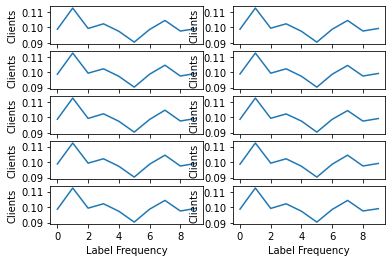

In [19]:
# gaussian ~ N(5, 1000)
values = [np.array([count_gaussian_1000.get(k).get(key) for key in count_gaussian_1000.get(k)]) for k in count_gaussian_1]
counts_normalized = [values[j] / values[j].sum() for j in range(len(values))]
counts_normalized

fig, axes = plt.subplots(5, 2)
for j in range(len(counts_normalized)):
    ax = sns.lineplot(counts_normalized[j], ax=axes[int(j / 2), j % 2])
    ax.set(xlabel="Label Frequency", ylabel="Clients")
plt.show()

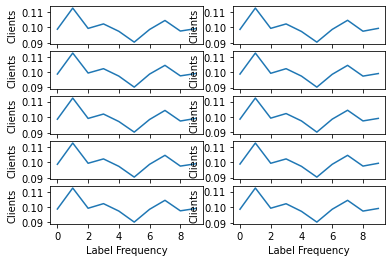

In [20]:
# gaussian ~ N(5, 20)
values = [np.array([count_gaussian_20.get(k).get(key) for key in count_gaussian_20.get(k)]) for k in count_gaussian_20]
counts_normalized = [values[j] / values[j].sum() for j in range(len(values))]
counts_normalized

fig, axes = plt.subplots(5, 2)
for j in range(len(counts_normalized)):
    ax = sns.lineplot(counts_normalized[j], ax=axes[int(j / 2), j % 2])
    ax.set(xlabel="Label Frequency", ylabel="Clients")
plt.show()

In [21]:
# same as sp.stats.entropy(p, q, base=2)
def kl_divergence(p, q):
    return sum(p[i] * math.log2(p[i] / q[i]) for i in range(len(p)) if q[i] != 0 and p[i] != 0)

# Jensen-Shannon Divergence
def js_divergence(p, q):
    m = 0.5 * (p + q)
    return 0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m)

In [26]:
def distance(y_train, subset_map, mode):
    N = y_train.shape[0]
    probs_original, probs = map_to_prob(y_train, {0: np.arange(60000)})[0], map_to_prob(y_train, subset_map)
    stats, pvals = [], []

    mode_dict = {
        "kolmogorov-smirnov": lambda x: kstest(x, probs_original),
        "empirical": lambda x: ks_2samp(ECDF(x)(x), ECDF(probs_original)(probs_original)),
        "cramer-von-mises": lambda x: cramervonmises(ECDF(x), ECDF(probs_original)),
        "pearson-chi-squared": lambda x: chisquare(x * N, probs_original * N),
        "anderson-darling": anderson_ksamp
    }
    
    mode_entropy = {
        "kl": lambda x: kl_divergence(x, probs_original),
        "js": lambda x: js_divergence(x, probs_original),
        "wd": lambda x: wasserstein_distance(x, probs_original)
    }

    if(mode in mode_entropy):
        try:
            test_func = mode_entropy[mode]
        except KeyError:
            raise ValueError(f"Invalid mode: {mode}")   
            
        stats, pvals = [test_func(probs[j]) for j in range(len(probs))], []
    else:
        try:
            test_func = mode_dict[mode]
        except KeyError:
            raise ValueError(f"Invalid mode: {mode}")
    
        stats, pvals = zip(*[test_func(probs[j]) for j in range(len(probs))])

    return stats, pvals

In [111]:
stats_ks_homo, pvals_ks_homo = distance(y_train, map_homo, "kolmogorov-smirnov")
stats_ks_homo, pvals_ks_homo

((0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1),
 (1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0))

In [112]:
stats_dir_05, vals_dir_05 = distance(y_train, map_dir_05, "kolmogorov-smirnov")
stats_dir_05, vals_dir_05 

((0.6,
  0.5,
  0.5555555555555556,
  0.7,
  0.7,
  0.6,
  0.5555555555555556,
  0.625,
  0.5555555555555556,
  0.8),
 (0.05244755244755244,
  0.16782134274394334,
  0.08391608391608392,
  0.012340600575894691,
  0.060606060606060615,
  0.05244755244755244,
  0.08391608391608392,
  0.037296037296037296,
  0.08391608391608392,
  0.002056766762649115))

In [25]:
stats_dir_1000, vals_dir_1000 = distance(y_train, map_dir_1000, "kolmogorov-smirnov")
stats_dir_1000, vals_dir_1000

((0.3, 0.3, 0.3, 0.3, 0.2, 0.4, 0.3, 0.4, 0.2, 0.3),
 (0.7869297884777761,
  0.7869297884777761,
  0.7869297884777761,
  0.7869297884777761,
  0.9944575548290717,
  0.41752365281777043,
  0.7869297884777761,
  0.41752365281777043,
  0.9944575548290717,
  0.7869297884777761))

In [27]:
stats_dir_1000, vals_dir_1000 = distance(y_train, map_dir_1000, "wd")
stats_dir_1000, vals_dir_1000

([0.0009782914795720408,
  0.0013529645059156812,
  0.002084822200066468,
  0.0009746855079821757,
  0.001444742973883274,
  0.0025178426142047367,
  0.002631073919107392,
  0.0014106947438235792,
  0.000515232986925912,
  0.0017748204450319493],
 [])

In [119]:
def run_experiment(alpha_vector, path, mode_part, mode_test, n_clients, logpath=None, save=False):
    x_train, y_train, x_test, y_test = get_data(path)
    evol_stat, evol_pval = [], []

    for j in range(len(alpha_vector)):
        a_j = alpha_vector[j]
        subset_map = partition(path, mode_part, n_clients, a_j)
        if save:
            tensor_to_csv(x_train, y_train, subset_map, j)
        stats, pvals = distance(y_train, subset_map, mode_test)
        mean_teststat_j = np.mean(stats)
        mean_pval_j = np.mean(pvals)
        evol_stat.append(mean_teststat_j)
        evol_pval.append(mean_pval_j)

    title_formats_part = {
        "hetero-dir": "Mean divergence from original distribution under (increasingly) heterogeneous partitioning via Dirichlet distribution",
        "hetero-gaussian": "Mean divergence from original distribution under (increasingly) heterogeneous partitioning via Gaussian distribution",
        "homo": "A homogeneous partitioning with {n_clients} subsets",
    }

    title_formats_test = {
        "kolmogorov-smirnov": "Test Statistic: Kolmogorov-Smirnov",
        "empirical": "Test Statistic: Empirical Distribution",
        "kl": "(Entropy-Based) Kullback-Leibler Divergence",
        "js": "(Entropy-Based) Jensen-Shannon Divergence"
    }

    def linplot(stats):
        main_title = title_formats_part.get(mode_part, "")
        main_title = main_title.format(n_clients=n_clients)
        appendage = title_formats_test.get(mode_test, "")
        main_title = main_title + '\n' + appendage

        plt.figure(figsize=(5, 3), dpi=300)
        plt.plot(np.arange(len(stats)), stats)
        plt.xlabel([f'α_{j}={alpha}' for j, alpha in enumerate(alpha_vector)])
        plt.xticks(np.arange(len(stats)))
        plt.suptitle(main_title)
        plt.show()

    linplot(evol_stat)

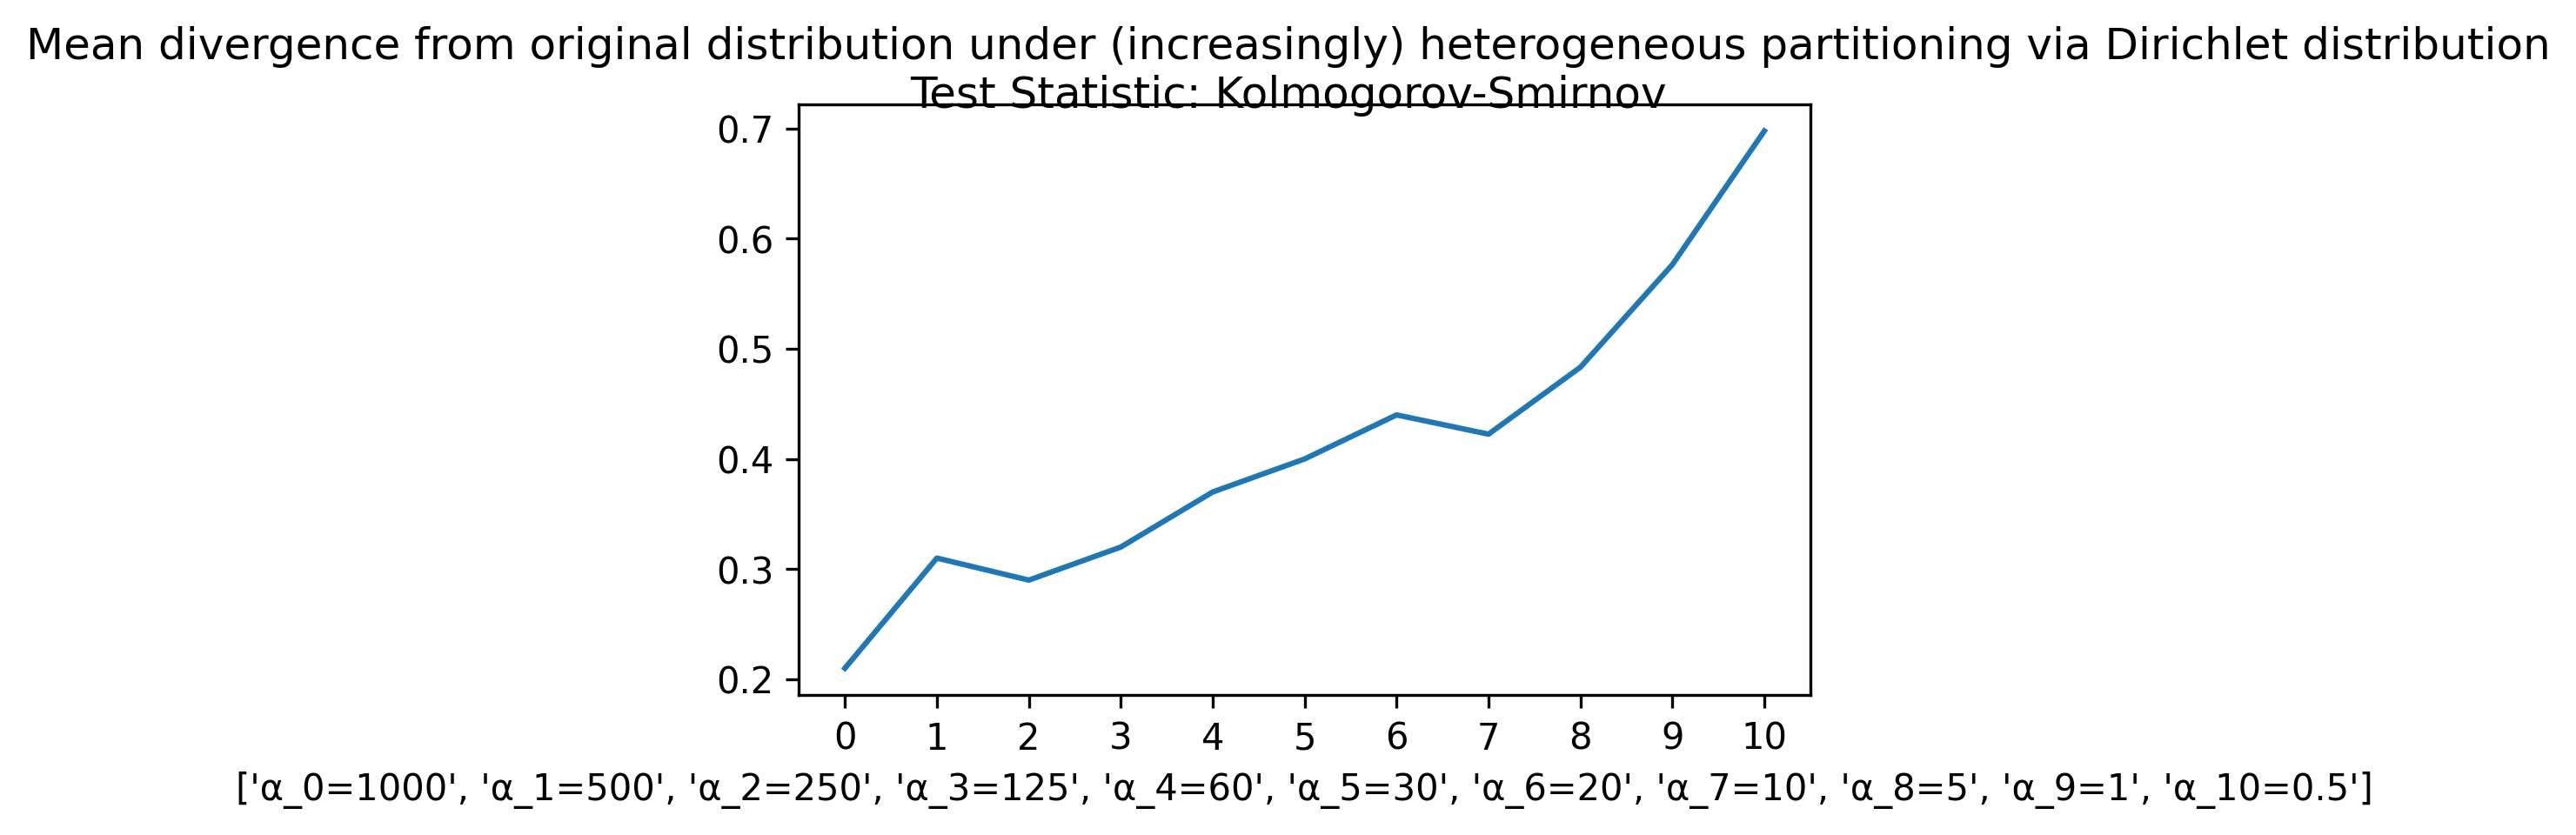

In [115]:
alpha_vector = [1000, 500, 250, 125, 60, 30, 20, 10, 5, 1, 0.5]
run_experiment(alpha_vector, "D:/", "hetero-dir", "kolmogorov-smirnov", 10)

C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Aybüke\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


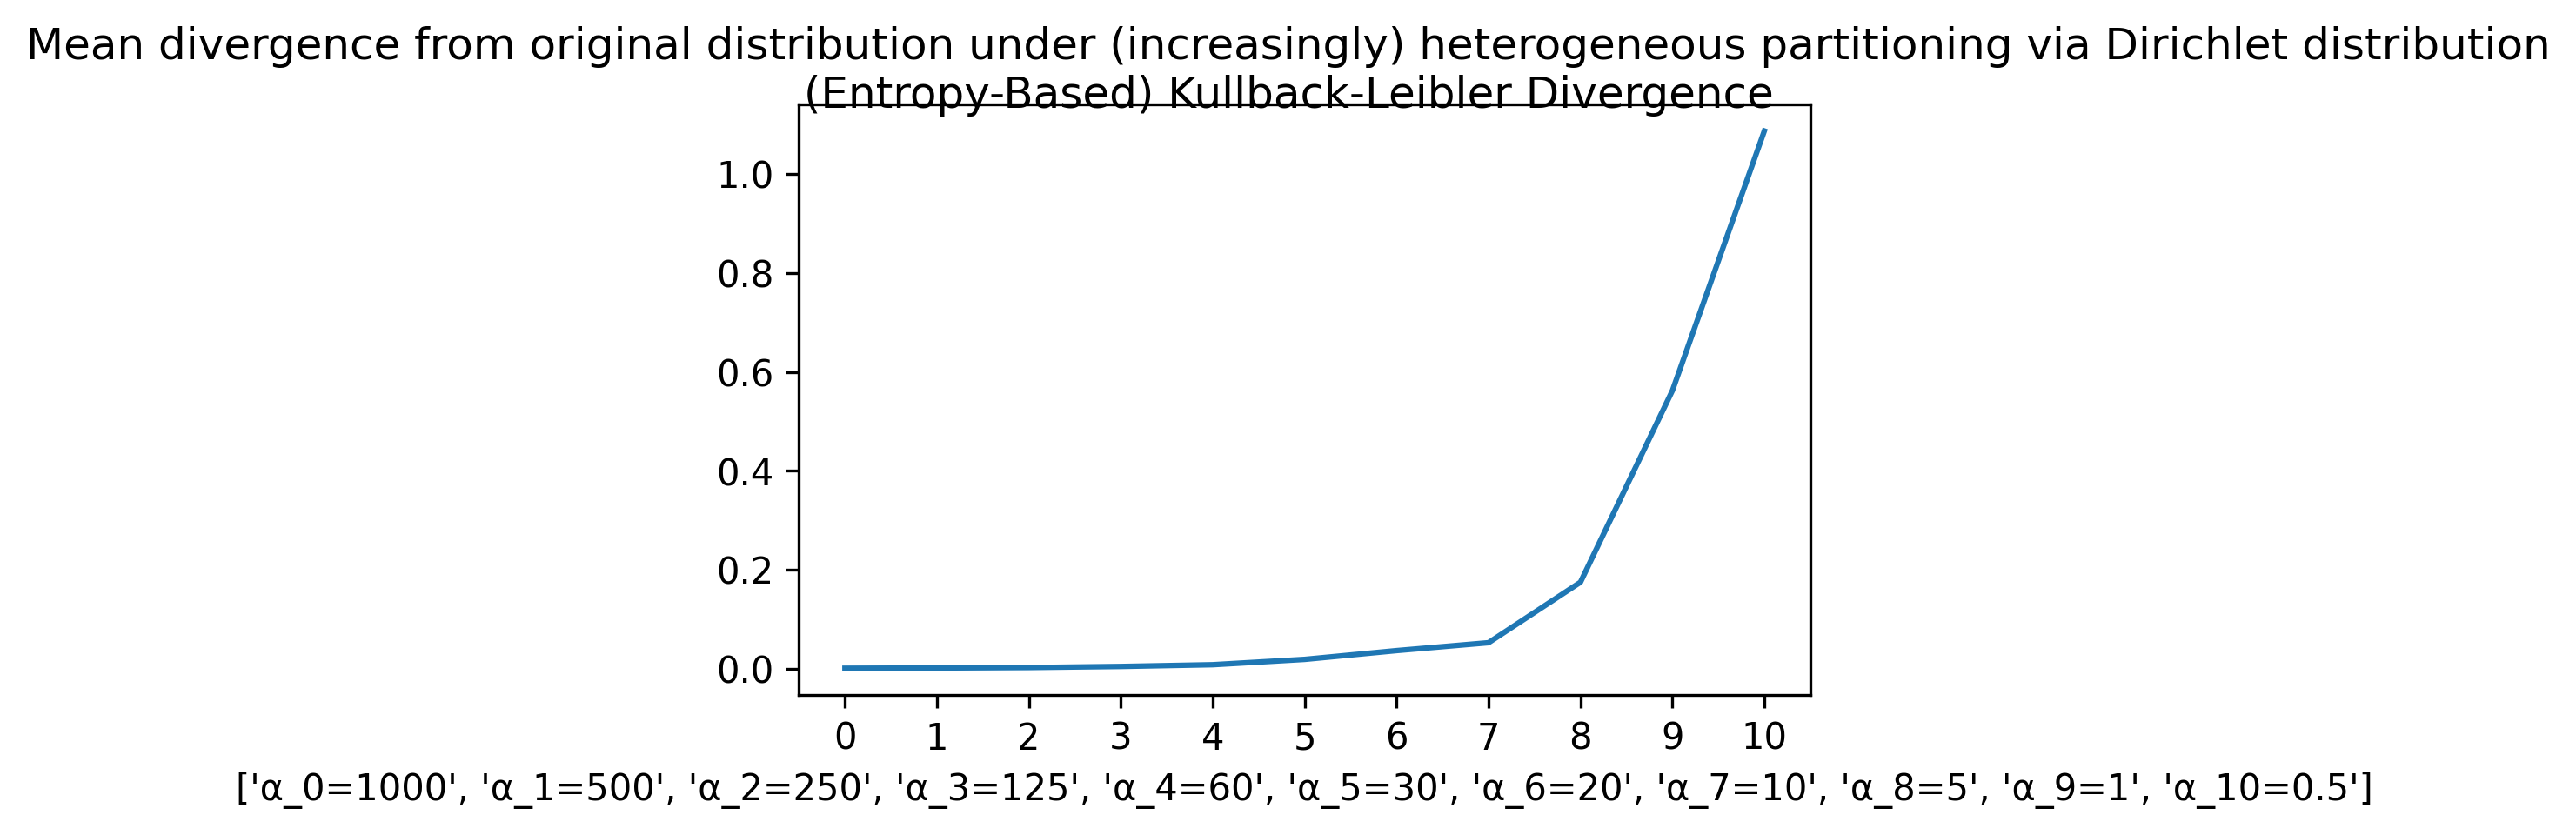

In [118]:
alpha_vector = [1000, 500, 250, 125, 60, 30, 20, 10, 5, 1, 0.5]
run_experiment(alpha_vector, "D:/", "hetero-dir", "kl", 10)